# Homework 6: CNNs


### Importing libraries

In [1]:
# install optuna if it is not already installed
import sys
!{sys.executable} -m pip install -q optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

import optuna

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import random

In [3]:
# setting seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### Loading the Fashion MNIST data

In [4]:
# importing Fashion MNIST data from keras
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)


### Class names

In [5]:
# class names for Fashion MNIST labels
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

### Visualizing the data

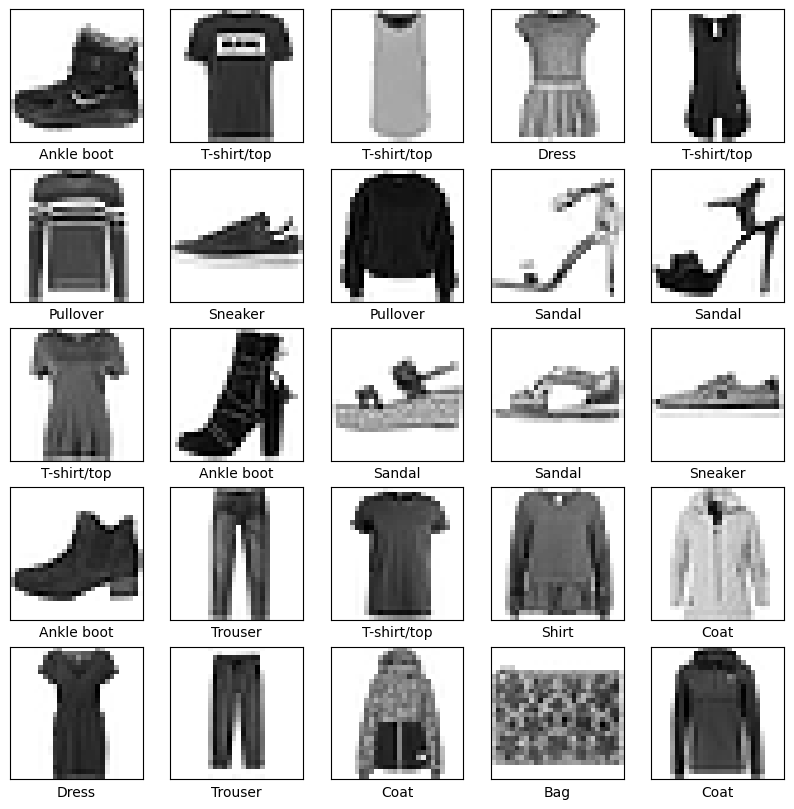

In [6]:
# visualize some of the training images
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

### Preprocessing the data


In [7]:
# Normalize pixel values to 0-1
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Add channel dimension for CNN input
X_train_cnn = X_train_norm[..., np.newaxis]
X_test_cnn = X_test_norm[..., np.newaxis]

print("CNN train shape:", X_train_cnn.shape)
print("CNN test shape:", X_test_cnn.shape)

CNN train shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


## Baseline CNN model


In [8]:
# define baseline CNN model
baseline_cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# compile the model
baseline_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# train baseline CNN model
baseline_history = baseline_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# evaluate baseline model on test set
baseline_loss, baseline_acc = baseline_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Baseline CNN Test Accuracy: {baseline_acc:.4f}")
print(f"Baseline CNN Test Loss: {baseline_loss:.4f}")

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8259 - loss: 0.5018 - val_accuracy: 0.8712 - val_loss: 0.3701
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8836 - loss: 0.3300 - val_accuracy: 0.8899 - val_loss: 0.3125
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8967 - loss: 0.2885 - val_accuracy: 0.8962 - val_loss: 0.2930
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9062 - loss: 0.2609 - val_accuracy: 0.8978 - val_loss: 0.2844
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9146 - loss: 0.2389 - val_accuracy: 0.8983 - val_loss: 0.2808
Baseline CNN Test Accuracy: 0.8926
Baseline CNN Test Loss: 0.2938


### Baseline training behavior

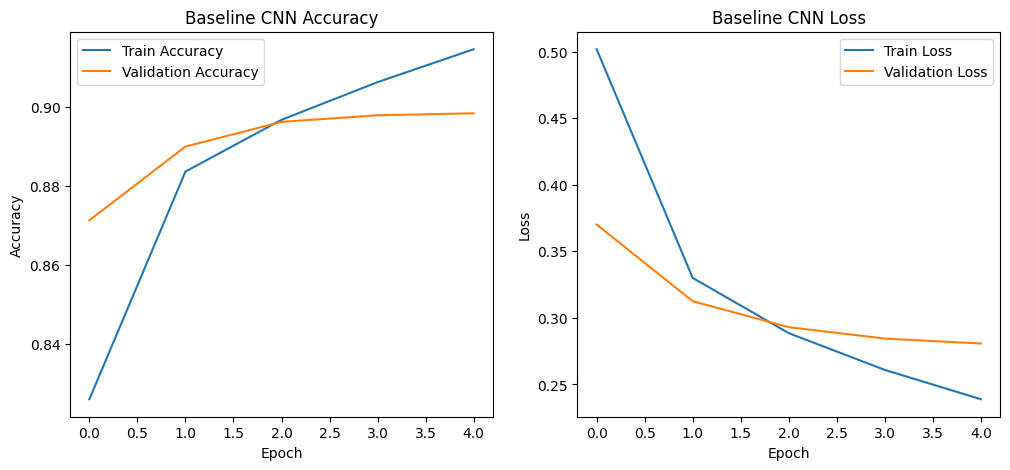

In [10]:
# visualizing train vs validation accuracy for baseline CNN model
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history["accuracy"], label="Train Accuracy")
plt.plot(baseline_history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Baseline CNN Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(baseline_history.history["loss"], label="Train Loss")
plt.plot(baseline_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN Loss")
plt.legend()

plt.show()

## Defining useful functions


In [11]:
# function to plot training history

def plot_history(history, title):
    plt.figure(figsize=(12,5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss")
    plt.legend()

    plt.show()


# function to evaluate and save model results

def evaluate_model(model, X_test_data, y_test_data, model_name):
    test_loss, test_acc = model.evaluate(X_test_data, y_test_data, verbose=0)

    y_pred_prob = model.predict(X_test_data, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred, average="weighted")
    recall = recall_score(y_test_data, y_pred, average="weighted")
    f1 = f1_score(y_test_data, y_pred, average="weighted")

    results = {
        "Model": model_name,
        "Test Loss": test_loss,
        "Test Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

    print(model_name)
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return results

## Experiment 1: Deeper CNN


In [12]:
# define deeper CNN model
cnn_deeper = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

cnn_deeper.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_deeper.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7848 - loss: 0.6052 - val_accuracy: 0.8537 - val_loss: 0.4186
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8612 - loss: 0.3881 - val_accuracy: 0.8686 - val_loss: 0.3692
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8796 - loss: 0.3367 - val_accuracy: 0.8802 - val_loss: 0.3348
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8895 - loss: 0.3061 - val_accuracy: 0.8856 - val_loss: 0.3173
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8973 - loss: 0.2837 - val_accuracy: 0.8899 - val_loss: 0.3066


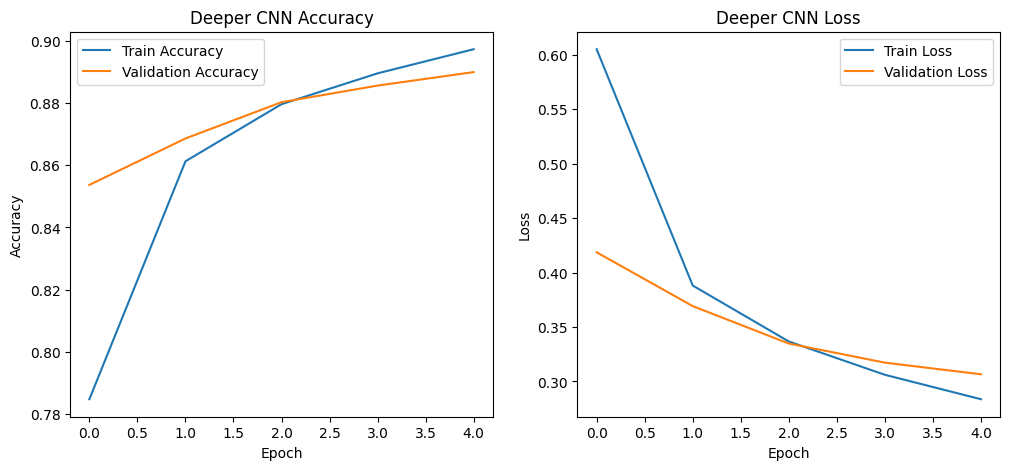

In [13]:
# train deeper CNN model
cnn_deeper_history = cnn_deeper.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# plot training behavior
plot_history(cnn_deeper_history, "Deeper CNN")

## Experiment 2: Dropout regularization


In [14]:
# define CNN model with dropout
cnn_dropout = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

cnn_dropout.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_dropout.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7330 - loss: 0.7300 - val_accuracy: 0.8226 - val_loss: 0.4763
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8269 - loss: 0.4799 - val_accuracy: 0.8587 - val_loss: 0.3996
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8484 - loss: 0.4187 - val_accuracy: 0.8688 - val_loss: 0.3574
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8631 - loss: 0.3845 - val_accuracy: 0.8799 - val_loss: 0.3303
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8698 - loss: 0.3598 - val_accuracy: 0.8791 - val_loss: 0.3261


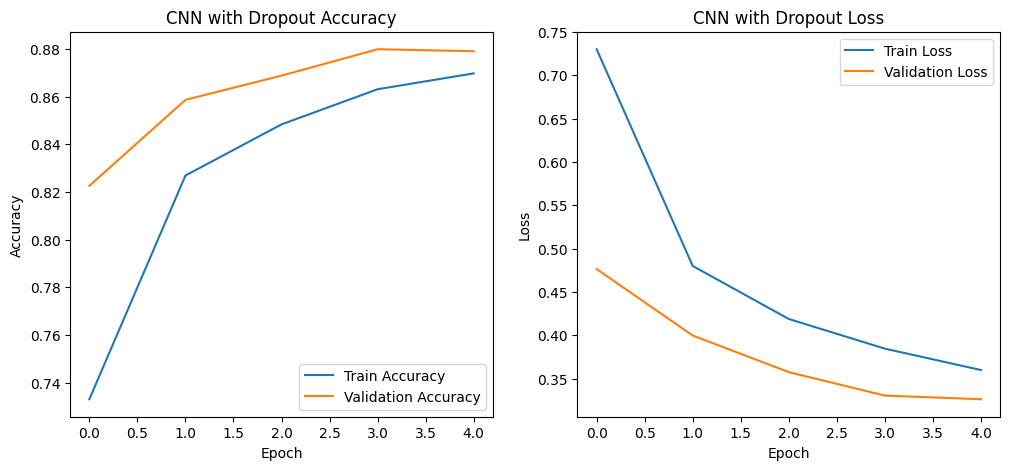

In [15]:
# train CNN model with dropout
cnn_dropout_history = cnn_dropout.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# plot training behavior
plot_history(cnn_dropout_history, "CNN with Dropout")

## Experiment 3: Data augmentation


In [16]:
# define data augmentation layer
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05)
])

# define CNN model with data augmentation and dropout
cnn_aug = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

cnn_aug.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cnn_aug.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.6892 - loss: 0.8563 - val_accuracy: 0.8018 - val_loss: 0.5273
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.7843 - loss: 0.5858 - val_accuracy: 0.8233 - val_loss: 0.4818
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8078 - loss: 0.5236 - val_accuracy: 0.8476 - val_loss: 0.4219
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8238 - loss: 0.4827 - val_accuracy: 0.8560 - val_loss: 0.3936
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8343 - loss: 0.4570 - val_accuracy: 0.8635 - val_loss: 0.3818


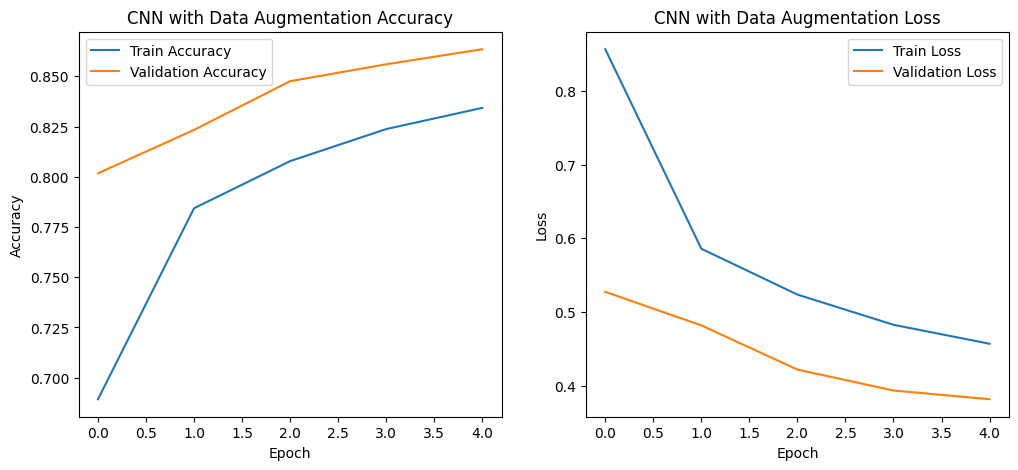

In [17]:
# train CNN model with data augmentation
cnn_aug_history = cnn_aug.fit(
    X_train_cnn,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# plot training behavior
plot_history(cnn_aug_history, "CNN with Data Augmentation")

## One-factor-at-a-time experiment: Dropout rate


In [18]:
# testing different dropout rates one factor at a time

dropout_rates = [0.0, 0.2, 0.4]
dropout_results = []
dropout_histories = {}

for rate in dropout_rates:
    print("Dropout rate:", rate)

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(rate),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_cnn,
        y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)

    dropout_results.append({
        "Dropout Rate": rate,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss,
        "Final Train Accuracy": history.history["accuracy"][-1],
        "Final Validation Accuracy": history.history["val_accuracy"][-1],
        "Final Train Loss": history.history["loss"][-1],
        "Final Validation Loss": history.history["val_loss"][-1]
    })

    dropout_histories[rate] = history

    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print()

# display results as dataframe
dropout_results_df = pd.DataFrame(dropout_results)
dropout_results_df

Dropout rate: 0.0
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7732 - loss: 0.6310 - val_accuracy: 0.8482 - val_loss: 0.4353
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8591 - loss: 0.3941 - val_accuracy: 0.8663 - val_loss: 0.3775
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8779 - loss: 0.3405 - val_accuracy: 0.8743 - val_loss: 0.3510
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8890 - loss: 0.3087 - val_accuracy: 0.8808 - val_loss: 0.3316
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8975 - loss: 0.2854 - val_accuracy: 0.8852 - val_loss: 0.3182
Test Accuracy: 0.8834
Test Loss: 0.3271

Dropout rate: 0.2
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7685 - loss: 0.6491 - val_accuracy: 0.8500 - val_loss: 0.4228
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8564 - loss: 0.4038 - val_accuracy: 0.8723 - val_loss: 0.3556
Epoch 3/5
375/375 ━━━━━━━━━

,Dropout Rate,Test Accuracy,Test Loss,Final Train Accuracy,Final Validation Accuracy,Final Train Loss,Final Validation Loss
0,0.0,0.8834,0.327051,0.897458,0.885250,0.285390,0.318172
1,0.2,0.8899,0.304238,0.892271,0.893083,0.297279,0.288611
2,0.4,0.8844,0.329666,0.867688,0.886750,0.368812,0.311745


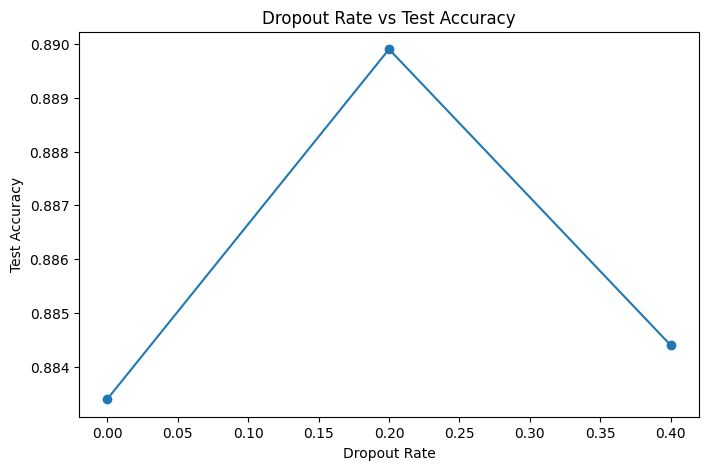

In [19]:
# plot dropout experiment results
plt.figure(figsize=(8, 5))
plt.plot(dropout_results_df["Dropout Rate"], dropout_results_df["Test Accuracy"], marker="o")
plt.xlabel("Dropout Rate")
plt.ylabel("Test Accuracy")
plt.title("Dropout Rate vs Test Accuracy")
plt.show()

## One-factor-at-a-time experiment: Batch size


In [20]:
# testing different batch sizes one factor at a time

batch_sizes = [32, 64, 128]
batch_results = []

for batch in batch_sizes:
    print("Batch size:", batch)

    model = models.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train_cnn,
        y_train,
        epochs=5,
        batch_size=batch,
        validation_split=0.2,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(X_test_cnn, y_test, verbose=0)

    batch_results.append({
        "Batch Size": batch,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss,
        "Final Train Accuracy": history.history["accuracy"][-1],
        "Final Validation Accuracy": history.history["val_accuracy"][-1],
        "Final Train Loss": history.history["loss"][-1],
        "Final Validation Loss": history.history["val_loss"][-1]
    })

    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print()

batch_results_df = pd.DataFrame(batch_results)
batch_results_df

Batch size: 32
Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7861 - loss: 0.5863 - val_accuracy: 0.8612 - val_loss: 0.3855
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8601 - loss: 0.3914 - val_accuracy: 0.8882 - val_loss: 0.3133
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8784 - loss: 0.3395 - val_accuracy: 0.8920 - val_loss: 0.2955
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8888 - loss: 0.3071 - val_accuracy: 0.8938 - val_loss: 0.2889
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8969 - loss: 0.2831 - val_accuracy: 0.8967 - val_loss: 0.2881
Test Accuracy: 0.8926
Test Loss: 0.3001

Batch size: 64
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.7705 - loss: 0.6400 - val_accuracy: 0.8587 - val_loss: 0.3966
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8535 - loss: 0.4118 - val_accuracy: 0.8754 - val_loss: 0.3421
Epoch 3/5
750/750 ━━━━━━━━━━━

,Batch Size,Test Accuracy,Test Loss,Final Train Accuracy,Final Validation Accuracy,Final Train Loss,Final Validation Loss
0,32,0.8926,0.300083,0.896917,0.896667,0.283095,0.288095
1,64,0.8914,0.296667,0.890979,0.896333,0.303142,0.282685
2,128,0.8837,0.313925,0.882500,0.889250,0.325893,0.300366


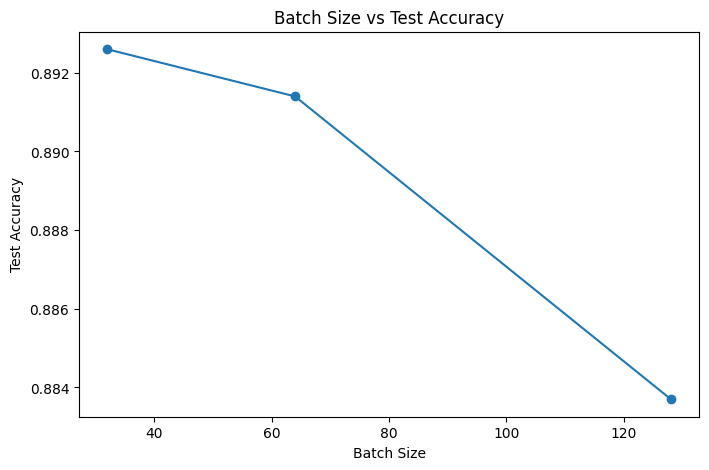

In [21]:
# plot batch size experiment results
plt.figure(figsize=(8, 5))
plt.plot(batch_results_df["Batch Size"], batch_results_df["Test Accuracy"], marker="o")
plt.xlabel("Batch Size")
plt.ylabel("Test Accuracy")
plt.title("Batch Size vs Test Accuracy")
plt.show()

## Comparing experiment results

In [22]:
# evaluating main experiment models
all_results = []

all_results.append(evaluate_model(baseline_cnn, X_test_cnn, y_test, "Baseline CNN"))
all_results.append(evaluate_model(cnn_deeper, X_test_cnn, y_test, "Deeper CNN"))
all_results.append(evaluate_model(cnn_dropout, X_test_cnn, y_test, "CNN with Dropout"))
all_results.append(evaluate_model(cnn_aug, X_test_cnn, y_test, "CNN with Data Augmentation"))

results_df = pd.DataFrame(all_results)
results_df

Baseline CNN
Test Accuracy: 0.8926
Precision: 0.8986
Recall: 0.8926
F1 Score: 0.8939
Deeper CNN
Test Accuracy: 0.8856
Precision: 0.8887
Recall: 0.8856
F1 Score: 0.8860
CNN with Dropout
Test Accuracy: 0.8738
Precision: 0.8754
Recall: 0.8738
F1 Score: 0.8737
CNN with Data Augmentation
Test Accuracy: 0.8581
Precision: 0.8617
Recall: 0.8581
F1 Score: 0.8591


,Model,Test Loss,Test Accuracy,Precision,Recall,F1 Score
0,Baseline CNN,0.293816,0.8926,0.898634,0.8926,0.893857
1,Deeper CNN,0.316315,0.8856,0.888695,0.8856,0.885963
2,CNN with Dropout,0.341929,0.8738,0.875410,0.8738,0.873651
3,CNN with Data Augmentation,0.400890,0.8581,0.861723,0.8581,0.859146


## Systematic tuning with Optuna

In [23]:
# define Optuna objective function

def objective(trial):
    num_conv_blocks = trial.suggest_int("num_conv_blocks", 1, 2)
    filters_1 = trial.suggest_categorical("filters_1", [16, 32, 64])
    filters_2 = trial.suggest_categorical("filters_2", [32, 64, 128])
    dense_units = trial.suggest_categorical("dense_units", [64, 128, 256])
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])

    model = models.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    model.add(layers.Conv2D(filters_1, (3, 3), activation="relu"))
    model.add(layers.MaxPooling2D((2, 2)))

    if num_conv_blocks == 2:
        model.add(layers.Conv2D(filters_2, (3, 3), activation="relu"))
        model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation="relu"))
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )

    history = model.fit(
        X_train_cnn,
        y_train,
        epochs=10,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )

    return min(history.history["val_loss"])

In [24]:
# run Optuna study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=10)

print("Best validation loss:", study.best_value)
print("Best parameters:")
print(study.best_params)

[I 2026-05-29 22:32:41,011] A new study created in memory with name: no-name-9eb7f7b9-1f44-43f8-8a4b-ae99bd6c944a


[I 2026-05-29 22:33:25,983] Trial 0 finished with value: 0.253627210855484 and parameters: {'num_conv_blocks': 2, 'filters_1': 16, 'filters_2': 64, 'dense_units': 128, 'dropout_rate': 0.49329655724355137, 'learning_rate': 0.0012986959498870537, 'batch_size': 64}. Best is trial 0 with value: 0.253627210855484.
[I 2026-05-29 22:35:59,943] Trial 1 finished with value: 0.26698336005210876 and parameters: {'num_conv_blocks': 2, 'filters_1': 64, 'filters_2': 128, 'dense_units': 64, 'dropout_rate': 0.3832312289570048, 'learning_rate': 0.002626212099018847, 'batch_size': 64}. Best is trial 0 with value: 0.253627210855484.
[I 2026-05-29 22:36:24,222] Trial 2 finished with value: 0.2816668152809143 and parameters: {'num_conv_blocks': 1, 'filters_1': 32, 'filters_2': 128, 'dense_units': 128, 'dropout_rate': 0.1154558063890546, 'learning_rate': 0.0049187663558637644, 'batch_size': 128}. Best is trial 0 with value: 0.253627210855484.
[I 2026-05-29 22:37:32,346] Trial 3 finished with value: 0.270293

Best validation loss: 0.253627210855484
Best parameters:
{'num_conv_blocks': 2, 'filters_1': 16, 'filters_2': 64, 'dense_units': 128, 'dropout_rate': 0.49329655724355137, 'learning_rate': 0.0012986959498870537, 'batch_size': 64}


In [25]:
# visualizing Optuna results
optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()
optuna.visualization.plot_slice(study).show()

## Building final CNN model using Optuna parameters

In [26]:
# get best parameters from Optuna
best_params = study.best_params

num_conv_blocks = best_params["num_conv_blocks"]
filters_1 = best_params["filters_1"]
filters_2 = best_params["filters_2"]
dense_units = best_params["dense_units"]
dropout_rate = best_params["dropout_rate"]
learning_rate = best_params["learning_rate"]
batch_size = best_params["batch_size"]

# build final model from best parameters
final_cnn = models.Sequential()
final_cnn.add(layers.Input(shape=(28, 28, 1)))

final_cnn.add(layers.Conv2D(filters_1, (3, 3), activation="relu"))
final_cnn.add(layers.MaxPooling2D((2, 2)))

if num_conv_blocks == 2:
    final_cnn.add(layers.Conv2D(filters_2, (3, 3), activation="relu"))
    final_cnn.add(layers.MaxPooling2D((2, 2)))

final_cnn.add(layers.Flatten())
final_cnn.add(layers.Dense(dense_units, activation="relu"))
final_cnn.add(layers.Dropout(dropout_rate))
final_cnn.add(layers.Dense(10, activation="softmax"))

final_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

final_cnn.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 11, 11, 64)     │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 215,658 (842.41 KB)

 Trainable params: 215,658 (842.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7783 - loss: 0.6181 - val_accuracy: 0.8623 - val_loss: 0.3849
Epoch 2/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8542 - loss: 0.4087 - val_accuracy: 0.8774 - val_loss: 0.3276
Epoch 3/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8716 - loss: 0.3550 - val_accuracy: 0.8857 - val_loss: 0.3051
Epoch 4/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8834 - loss: 0.3227 - val_accuracy: 0.8962 - val_loss: 0.2821
Epoch 5/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8920 - loss: 0.2970 - val_accuracy: 0.9022 - val_loss: 0.2662
Epoch 6/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8991 - loss: 0.2774 - val_accuracy: 0.9014 - val_loss: 0.2670
Epoch 7/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9059 - loss: 0.2579 - val_accuracy: 0.9021 - val_loss: 0.2647
Epoch 8/25
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9126 - loss: 0.2411 - val_accuracy: 0.

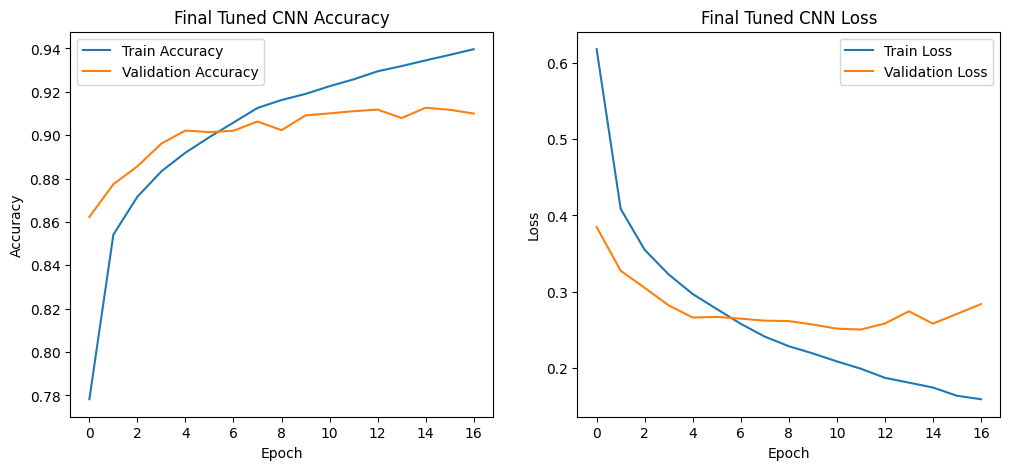

In [27]:
# train final CNN model
final_early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_history = final_cnn.fit(
    X_train_cnn,
    y_train,
    epochs=25,
    batch_size=batch_size,
    validation_split=0.2,
    callbacks=[final_early_stop],
    verbose=1
)

plot_history(final_history, "Final Tuned CNN")

## Final model evaluation on held-out test set

In [28]:
# evaluate final CNN model on test data
final_loss, final_acc = final_cnn.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Final CNN Test Accuracy: {final_acc:.4f}")
print(f"Final CNN Test Loss: {final_loss:.4f}")

# predictions
final_pred_prob = final_cnn.predict(X_test_cnn, verbose=0)
final_pred = np.argmax(final_pred_prob, axis=1)

# classification metrics
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred, average="weighted")
final_recall = recall_score(y_test, final_pred, average="weighted")
final_f1 = f1_score(y_test, final_pred, average="weighted")

print("Final Model Test Set Evaluation:")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall: {final_recall:.4f}")
print(f"F1 Score: {final_f1:.4f}")

Final CNN Test Accuracy: 0.9049
Final CNN Test Loss: 0.2702
Final Model Test Set Evaluation:
Accuracy: 0.9049
Precision: 0.9079
Recall: 0.9049
F1 Score: 0.9056


In [29]:
# classification report
print(classification_report(y_test, final_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/top       0.89      0.80      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.83      0.88      0.86      1000
       Dress       0.89      0.92      0.90      1000
        Coat       0.89      0.81      0.85      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.70      0.78      0.74      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.99      0.97      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.91     10000
weighted avg       0.91      0.90      0.91     10000



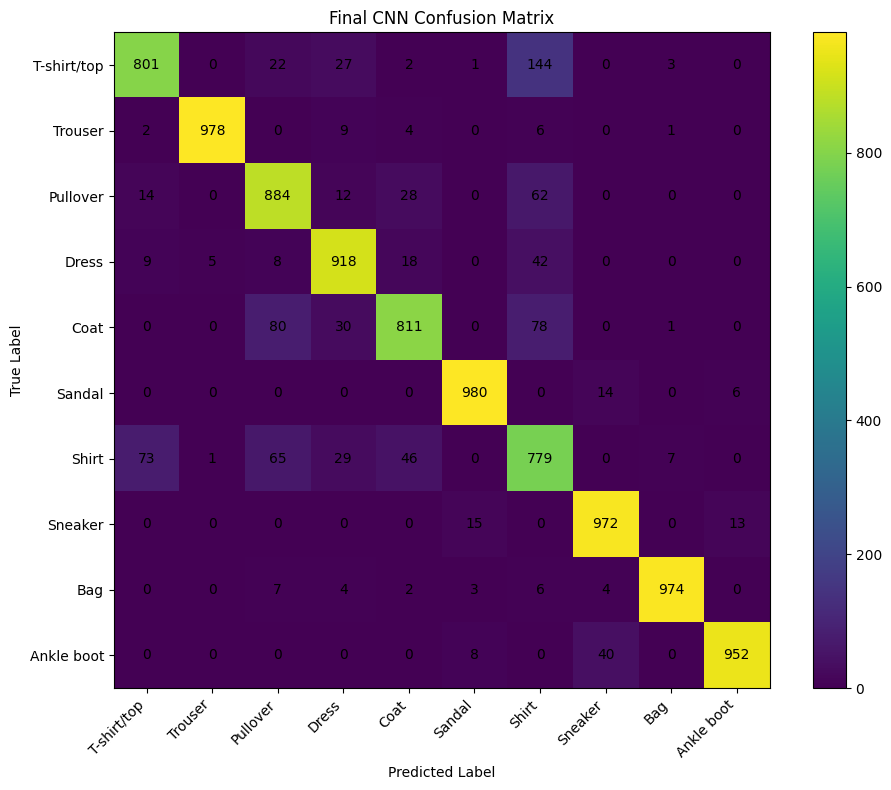

In [30]:
# confusion matrix
cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Final CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### Visualizing incorrect predictions

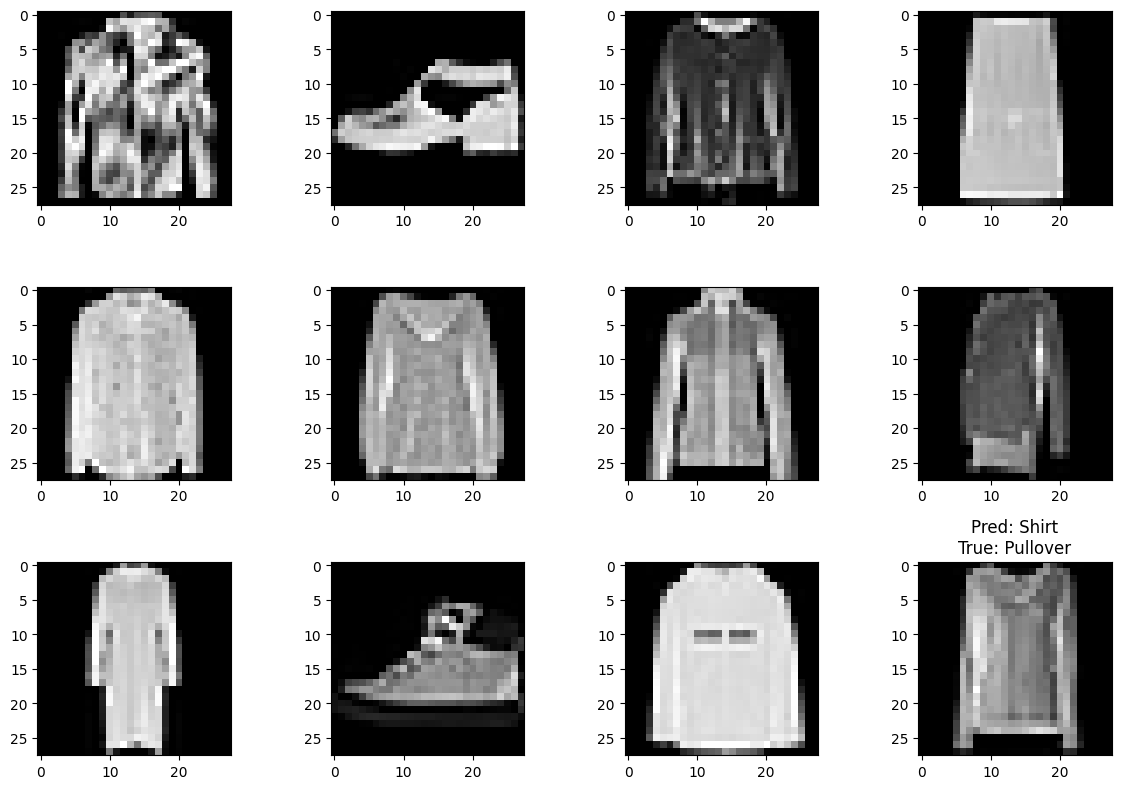

In [31]:
# show a few misclassified images
wrong_index = np.where(final_pred != y_test)[0]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(wrong_index[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[idx], cmap="gray")
plt.title(
    f"Pred: {class_names[final_pred[idx]]}\nTrue: {class_names[y_test[idx]]}"
)

plt.tight_layout()
plt.show()

## Final comparison table

In [32]:
# add final model to the comparison table
final_result = {
    "Model": "Final Tuned CNN",
    "Test Loss": final_loss,
    "Test Accuracy": final_accuracy,
    "Precision": final_precision,
    "Recall": final_recall,
    "F1 Score": final_f1
}

final_results_df = pd.concat([results_df, pd.DataFrame([final_result])], ignore_index=True)
final_results_df

,Model,Test Loss,Test Accuracy,Precision,Recall,F1 Score
0,Baseline CNN,0.293816,0.8926,0.898634,0.8926,0.893857
1,Deeper CNN,0.316315,0.8856,0.888695,0.8856,0.885963
2,CNN with Dropout,0.341929,0.8738,0.875410,0.8738,0.873651
3,CNN with Data Augmentation,0.400890,0.8581,0.861723,0.8581,0.859146
4,Final Tuned CNN,0.270249,0.9049,0.907906,0.9049,0.905594


## Conclusion

Overall, the final tuned CNN was the strongest model in this assignment. It achieved a test accuracy of 0.9049 and an F1 score of 0.9056, which improved on the baseline CNN accuracy of 0.8926. The final model also had the lowest test loss at 0.2702, showing that the Optuna tuning process helped identify a better balance of model structure and hyperparameters.

The results show that adding more complexity did not always improve performance. The deeper CNN, dropout model, and data augmentation model all performed worse than the baseline, while the tuned CNN performed best. This suggests that the most helpful improvement was not simply adding layers, but choosing better values for the learning rate, filters, dropout rate, dense units, and batch size. The Optuna importance plot also showed that learning rate was the most important hyperparameter, meaning the way the model learned during training had a major effect on performance.

The confusion matrix showed that the model classified distinct categories like trouser, sandal, sneaker, bag, and ankle boot very well. Most errors came from visually similar clothing categories, especially shirt, T-shirt/top, pullover, and coat. This makes sense because these items have similar shapes in low-resolution grayscale images. In the future, I would try early stopping, stronger regularization, or more targeted augmentation to reduce overfitting and improve performance on these harder clothing classes.


## Personal workflow for building CNN models in the future

For future CNN projects, I would start by loading and checking the image data, then normalize and reshape the inputs so they are ready for a CNN. I would first build a simple baseline CNN to understand the starting performance. After that, I would run experiments that change one factor at a time, such as model depth, dropout, filters, or data augmentation, so I can clearly see what helps and what hurts performance.

Once I understand the general model behavior, I would use a systematic tuning method like Optuna to search for stronger hyperparameters. I would compare models using validation accuracy, validation loss, test accuracy, precision, recall, F1 score, and the confusion matrix. I would also watch for overfitting by comparing training and validation curves. In the future, I would prioritize models that generalize well instead of only choosing the model with the highest training accuracy